<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Analytical_Versus_Numerical_Jacobians_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# The % ensures it binds immediately to this specific notebook kernel
%pip install cupy-cuda12x sympy

Initializing functions and allocating GPU memory...

--- RESULTS ---
Data points evaluated: 10,000,000
Analytical Time:       0.0014 seconds
Numerical Time:        0.0077 seconds
Max Absolute Error:    2.68e-03


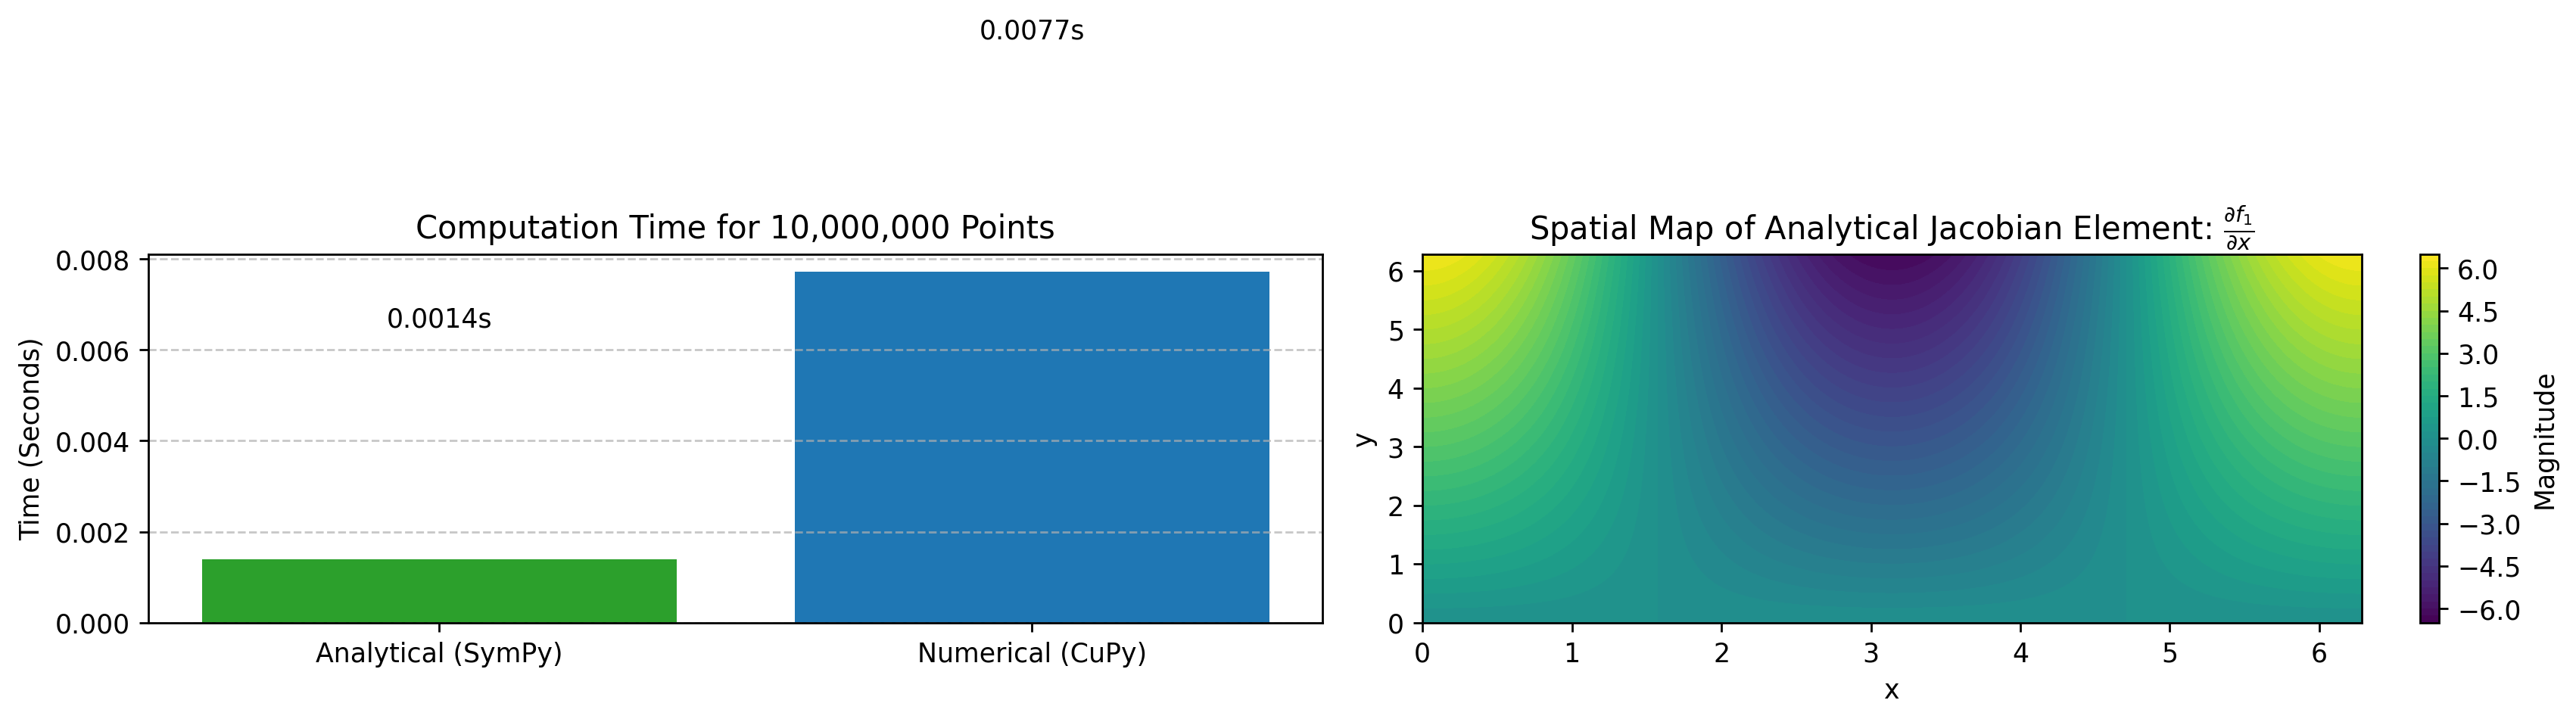

In [7]:
"""Evaluate and visualize analytical vs. numerical Jacobians on a GPU.

This script uses SymPy to derive an analytical Jacobian and CuPy to
evaluate it over millions of points, comparing performance and accuracy
against a numerical finite difference method.
"""

import time

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

plt.rcParams['figure.dpi'] = 250


def generate_analytical_jacobian():
    """Derive the Jacobian matrix symbolically and lambdify for CuPy.

    Returns:
        callable: A function that computes the Jacobian using CuPy backends.
    """
    x, y = sp.symbols('x y')
    f1 = sp.sin(x) * y
    f2 = x**2 + sp.exp(y)

    funcs = sp.Matrix([f1, f2])
    vars_matrix = sp.Matrix([x, y])

    j_sym = funcs.jacobian(vars_matrix)

    # Modules='cupy' bridges the analytical math to GPU acceleration
    return sp.lambdify((x, y), j_sym, modules='cupy')


def compute_numerical_jacobian(x_val, y_val, h=1e-5):
    """Compute the Jacobian matrix numerically using finite differences.

    Args:
        x_val (cupy.ndarray): The x-coordinate tensor.
        y_val (cupy.ndarray): The y-coordinate tensor.
        h (float, optional): The finite difference step size. Defaults to 1e-5.

    Returns:
        cupy.ndarray: A 2x2xN array representing the numerical Jacobian.
    """
    # Base evaluations
    f1_base = cp.sin(x_val) * y_val
    f2_base = x_val**2 + cp.exp(y_val)

    # Perturb x
    f1_dx = cp.sin(x_val + h) * y_val
    f2_dx = (x_val + h)**2 + cp.exp(y_val)

    # Perturb y
    f1_dy = cp.sin(x_val) * (y_val + h)
    f2_dy = x_val**2 + cp.exp(y_val + h)

    # Calculate gradients
    df1_dx = (f1_dx - f1_base) / h
    df1_dy = (f1_dy - f1_base) / h
    df2_dx = (f2_dx - f2_base) / h
    df2_dy = (f2_dy - f2_base) / h

    return cp.array([[df1_dx, df1_dy], [df2_dx, df2_dy]])


def run_benchmark_and_visualize():
    """Execute the GPU showdown, print metrics, and plot the results."""
    print("Initializing functions and allocating GPU memory...")
    j_analytical = generate_analytical_jacobian()

    # Generate massive 1D arrays for benchmarking
    n_points = 10_000_000
    x_data = cp.random.rand(n_points) * 2 * cp.pi
    y_data = cp.random.rand(n_points) * 2 * cp.pi

    # --- 1. Analytical Benchmark ---
    cp.cuda.Stream.null.synchronize()  # Wait for memory allocation to finish
    start_time = time.time()

    res_analytical = j_analytical(x_data, y_data)

    cp.cuda.Stream.null.synchronize()  # Wait for compute to finish
    time_analytical = time.time() - start_time

    # --- 2. Numerical Benchmark ---
    start_time = time.time()

    res_numerical = compute_numerical_jacobian(x_data, y_data)

    cp.cuda.Stream.null.synchronize()
    time_numerical = time.time() - start_time

    # --- 3. Verification ---
    # Calculate the maximum absolute error across all 10M matrices
    max_error = cp.max(cp.abs(res_analytical - res_numerical))

    print("\n--- RESULTS ---")
    print(f"Data points evaluated: {n_points:,}")
    print(f"Analytical Time:       {time_analytical:.4f} seconds")
    print(f"Numerical Time:        {time_numerical:.4f} seconds")
    print(f"Max Absolute Error:    {max_error:.2e}")

    if max_error < 1e-4:
        print("Status: SUCCESS - The numerical approximation matches the exact formula!")

    # --- 4. Visualization ---
    # To make a meaningful plot, we use a structured 2D grid instead of random noise
    grid_size = 500
    x_grid = cp.linspace(0, 2 * cp.pi, grid_size)
    y_grid = cp.linspace(0, 2 * cp.pi, grid_size)
    x_mesh, y_mesh = cp.meshgrid(x_grid, y_grid)

    # Calculate the analytical Jacobian over the spatial grid
    j_mesh = j_analytical(x_mesh, y_mesh)

    # Transfer data from GPU VRAM to CPU RAM for Matplotlib
    # We will plot the top-left element of the Jacobian: df1/dx
    df1_dx_cpu = j_mesh[0][0].get()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Performance Bar Chart
    bars = axes[0].bar(
        ['Analytical (SymPy)', 'Numerical (CuPy)'],
        [time_analytical, time_numerical],
        color=['#2ca02c', '#1f77b4']
    )
    axes[0].set_title(f'Computation Time for {n_points:,} Points')
    axes[0].set_ylabel('Time (Seconds)')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Add timing text on top of bars
    for bar in bars:
        yval = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            yval + 0.005,
            f'{yval:.4f}s',
            ha='center',
            va='bottom'
        )

    # Plot 2: Heatmap of df1/dx
    contour = axes[1].contourf(
        x_grid.get(), y_grid.get(), df1_dx_cpu, levels=50, cmap='viridis'
    )
    fig.colorbar(contour, ax=axes[1], label='Magnitude')
    axes[1].set_title(r'Spatial Map of Analytical Jacobian Element: $\frac{\partial f_1}{\partial x}$')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    run_benchmark_and_visualize()